In [3]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path

In [4]:
import pandas as pd
from scipy.optimize import curve_fit

## Function to find red and green point

In [5]:
# HSV ranges (OpenCV scale: H 0-179, S/V 0-255) as lists of (lower, upper) pairs.
# Red wraps around the hue axis, so it needs two ranges.
COLOR_RANGES = {
    "red": [
        ((0, 80, 50), (10, 255, 255)),
        ((170, 80, 50), (180, 255, 255)),
    ],
    "green": [
        ((35, 80, 50), (85, 255, 255)),
    ],
}


def detect_point(frame, color="red", annotated=None):
    """
    Detect the largest blob of the given color in the frame and return its centroid (x, y).

    Parameters:
        frame: BGR image.
        color: "red" or "green" (any key of COLOR_RANGES).
        annotated: optional image to draw on (e.g. the output of a previous
            detect_point call) so several colors end up in one annotated frame.
            If None, a copy of `frame` is used.
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no object of that color is detected.
    """
    if color not in COLOR_RANGES:
        raise ValueError(
            f"Unsupported color '{color}'. Choose from: {list(COLOR_RANGES)}"
        )

    if annotated is None:
        annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in COLOR_RANGES[color]:
        mask = cv2.bitwise_or(
            mask, cv2.inRange(hsv, np.array(lower), np.array(upper))
        )

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"{color} ({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [6]:
# Function to process video and track colored points
def process_video(video_path, output_csv, preview=True, save_annotated=False, colors=("red", "green")):
    """
    Track one point per color in `colors`. The CSV has the columns
    frame, time_s, <color>_x, <color>_y for each color, in the given order.
    The same data is returned as a pandas DataFrame.
    """
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(video_path.stem + "_tracked.mp4")
        writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        time_s = frame_idx / fps if fps > 0 else np.nan
        row = {"frame": frame_idx, "time_s": time_s}

        annotated = None
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        for color in colors:
            x, y, color_mask, annotated = detect_point(frame, color, annotated)
            row[f"{color}_x"] = x
            row[f"{color}_y"] = y
            mask = cv2.bitwise_or(mask, color_mask)

        results.append(row)

        if writer is not None:
            writer.write(annotated)

        if preview:
            combined_mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            top = np.hstack((frame, annotated))
            bottom = np.hstack((combined_mask, np.zeros_like(combined_mask)))
            display = np.vstack((top, bottom))

            scale = 0.4
            display = cv2.resize(display, None, fx=scale, fy=scale)

            cv2.imshow("Original | Annotated / Mask", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()

    coord_cols = [f"{c}_{axis}" for c in colors for axis in ("x", "y")]
    df = pd.DataFrame(results).astype({col: float for col in coord_cols})
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")
    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    print(f"Frames processed: {len(df)}")
    for color in colors:
        missing = df[f"{color}_x"].isna().sum()
        print(f"Frames with missing {color} detection: {missing}")

    return df

In [7]:
# Function to export the first frame of a video as a PNG image
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [8]:
# export_first_frame(
#     video_path=video,
#     output_png="20260710_141408_first_frame.png",
#     dpi=300
# )

In [9]:
# The notebook lives in notebooks/, the videos in <project root>/videos
root = Path.cwd() if (Path.cwd() / "videos").exists() else Path.cwd().parent

In [10]:
video = root / "videos" / "30_A.mp4"
output = root / "videos" / "30_A.csv"

res_30A = process_video(
    video_path=video,
    output_csv=output,
    preview=False,
    save_annotated=True
)


Done. Saved coordinates to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_A.csv
Saved annotated video to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_A_tracked.mp4
Frames processed: 324
Frames with missing red detection: 66
Frames with missing green detection: 4


In [11]:
#function to convert pixel coordinates to meters
def pixels_to_m(x_pixel, y_pixel, scale, origin_x, origin_y):
    """
    Convert pixel coordinates to meters.

    Parameters:
    x_pixel (float): x coordinate in pixels
    y_pixel (float): y coordinate in pixels
    scale (float): scale factor (pixels per meter)
    origin_x (float): x coordinate of the origin in pixels
    origin_y (float): y coordinate of the origin in pixels

    Returns:
    (float, float): coordinates in meters
    """
    x_m = (x_pixel - origin_x) / scale
    y_m = -(y_pixel - origin_y) / scale # y points upward
    return x_m, y_m

In [12]:
# Calculating scale
# Assuming we know the real-world distance between two points in meters and their pixel coordinates
real_distance_m = 25.3e-2  # meters
x1_pixel = 963  #  pixel coordinates of the first point
y1_pixel = 156  #  pixel coordinates of the first point
x2_pixel = 1270  #  pixel coordinates of the second point
y2_pixel = 619  # pixel coordinates of the second point
pixel_distance = ((x2_pixel - x1_pixel)**2 + (y2_pixel - y1_pixel)**2)**0.5
scale = pixel_distance / real_distance_m
scale

2195.7864717736006

In [13]:
def cut_video(result, first_frame, last_frame=None):
    """
    Cut a video to include only frames from first_frame to last_frame.

    Parameters:
    result : Pandas dataframe as returned by the function process_video.
    first_frame (int): Index of the first frame to keep.
    last_frame (int, optional): Index of the last frame to keep. If None, keep until the end.

    Returns:
    Modified Pandas dataframe..
    """
    mask = result["frame"] >= first_frame
    if last_frame is not None:
        mask &= result["frame"] <= last_frame

    return result.loc[mask].reset_index(drop=True)

In [14]:
# cut_result = cut_video(res, 22)

# cut_result

In [15]:
def analyze_video(result, first_frame, last_frame=None, scale=scale, origin_x=0, origin_y=0, max_gap_frames=5,
                  m_red=270.5e-3, m_green=200.2e-3, L_red=12.9e-2, L_green=7e-2):
    """
    m_red, m_green: masses (kg); L_red, L_green: lengths (m) of the first and second rod.
    max_gap_frames: gaps of at most this many consecutive missing frames are filled by
    PCHIP interpolation (against time_s); longer gaps stay NaN. None disables interpolation.
    """
    # creating  a copy  of result to work with
    result = result.copy()
    cut_result = cut_video(result, first_frame, last_frame)
    # Addding columns which show x and y coordinates for red and green dots in meters
    result_with_m = cut_result.copy()
    # Shift time so that the first frame of the cut is at t = 0
    result_with_m["time_s"] = result_with_m["time_s"] - result_with_m["time_s"].min()
    for color in ("red", "green"):
        x_m, y_m = pixels_to_m(
            cut_result[f"{color}_x"], cut_result[f"{color}_y"], scale, origin_x, origin_y
        )
        result_with_m[f"{color}_x_m"] = x_m
        result_with_m[f"{color}_y_m"] = y_m

    # Fill short gaps in the coordinates (not in the angles, which can wrap around at +-pi)
    coord_cols = [f"{c}_{axis}_m" for c in ("red", "green") for axis in ("x", "y")]
    if max_gap_frames is None:
        interpolated = result_with_m[coord_cols]
    else:
        coords = result_with_m.set_index("time_s")[coord_cols]
        interpolated = coords.interpolate(method="pchip", limit_area="inside")
        for col in coord_cols:
            # Length of the run of missing values each NaN belongs to; leave long gaps unfilled
            missing = coords[col].isna()
            gap_length = missing.groupby((~missing).cumsum()).transform("sum")
            interpolated.loc[missing & (gap_length > max_gap_frames), col] = np.nan
    for col in coord_cols:
        result_with_m[f"{col[:-2]}_m_interpolated"] = interpolated[col].to_numpy()

    # Angle (radians) of the red dot measured from the vertical (y) axis
    result_with_m["phi_red"] = np.arctan2(
        result_with_m["red_x_m_interpolated"], -result_with_m["red_y_m_interpolated"]
    )
    # Angle (radians) of the green dot relative to the red dot, measured from the vertical (y) axis
    result_with_m["phi_green"] = np.arctan2(
        result_with_m["green_x_m_interpolated"] - result_with_m["red_x_m_interpolated"],
        -result_with_m["green_y_m_interpolated"] + result_with_m["red_y_m_interpolated"],
    )

    # Angular velocities (rad/s) by central differences. Unwrap first so that the jump at +-pi
    # does not show up as a spike; NaNs are skipped and stay NaN (np.gradient spreads them to neighbours).
    time = result_with_m["time_s"].to_numpy()
    for color in ("red", "green"):
        phi = result_with_m[f"phi_{color}"].to_numpy()
        valid = ~np.isnan(phi)
        phi_unwrapped = np.full_like(phi, np.nan)
        phi_unwrapped[valid] = np.unwrap(phi[valid])
        result_with_m[f"omega_{color}"] = np.gradient(phi_unwrapped, time)

    # Generalized momentum of the red point
    cos_phi_diff = np.cos(result_with_m["phi_red"] - result_with_m["phi_green"])
    result_with_m["p_red"] = (
        (m_red + m_green) * L_red**2 * result_with_m["omega_red"]
        + m_green * L_green * L_red * result_with_m["omega_green"] * cos_phi_diff
    )

    # Generalized momentum of the green point
    result_with_m["p_green"] = (
        m_green * L_green**2 * result_with_m["omega_green"]
        + m_green * L_green * L_red * result_with_m["omega_red"] * cos_phi_diff
    )

    return result_with_m[["time_s", "phi_red", "phi_green", "omega_red", "omega_green", "p_red", "p_green"]]

In [16]:
import matplotlib.pyplot as plt


def plot_results(analyzed_result, title="Pendulum angles"):
    """Plot the angles phi_red and phi_green as a function of time_s."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(analyzed_result["time_s"], analyzed_result["phi_red"], "r.", label="phi_red")
    ax.plot(analyzed_result["time_s"], analyzed_result["phi_green"], "g.", label="phi_green")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("angle (rad)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    plt.show()

In [17]:
def join_runs(df_A, df_B, label_A="A", label_B="B", variables=("phi_red", "phi_green", "p_green", "p_red")):
    """
    Join two analyzed runs on time and compute their phase-space distance.

    Parameters:
    df_A, df_B : Pandas dataframes as returned by analyze_video (with a time_s column).
    label_A, label_B (str): Suffixes for the columns of each run, e.g. "30A" gives phi_red_30A.
    variables : Columns to normalize and to use in the phase-space distance.

    The runs may have slightly different frame rates, so each row of df_A is matched to the nearest
    time of df_B (within half a frame) and only rows present in both runs are kept. time_s is taken
    from df_A, the matched time of df_B is kept as time_s_<label_B>.

    Each variable of both runs is divided by its largest absolute value over both runs (columns
    <variable>_<label>_norm). delta is the phase-space distance between the two runs:
    sqrt(sum over variables of (norm_A - norm_B)^2).

    Returns:
    Pandas dataframe with only the columns time_s, delta and ln_delta (natural logarithm of delta).
    """
    frame_period = df_A["time_s"].diff().median()

    joined = pd.merge_asof(
        df_A.add_suffix(f"_{label_A}").rename(columns={f"time_s_{label_A}": "time_s"}),
        df_B.add_suffix(f"_{label_B}"),
        left_on="time_s",
        right_on=f"time_s_{label_B}",
        direction="nearest",
        tolerance=frame_period / 2,
    ).dropna(subset=[f"time_s_{label_B}"]).reset_index(drop=True)

    for var in variables:
        var_max = max(joined[f"{var}_{label_A}"].abs().max(), joined[f"{var}_{label_B}"].abs().max())
        for label in (label_A, label_B):
            joined[f"{var}_{label}_norm"] = joined[f"{var}_{label}"] / var_max

    joined["delta"] = np.sqrt(
        sum(
            (joined[f"{var}_{label_A}_norm"] - joined[f"{var}_{label_B}_norm"]) ** 2
            for var in variables
        )
    )

    joined["ln_delta"] = np.log(joined["delta"])

    return joined[["time_s", "delta", "ln_delta"]]

In [18]:
def plot_joined(joined, title="Phase-space distance between runs", time_interval=None):
    """
    Plot ln_delta as a function of time_s for a dataframe returned by join_runs.
    Non-finite values (e.g. ln(0)) are skipped. time_interval is an optional
    (t_start, t_end) tuple in seconds to restrict the plot.

    Since delta(t) = delta_0 * exp(lambda * t), ln(delta) is linear in t. A straight line is fitted
    to the (cut) data; its slope is lambda.

    Returns:
    (lam, lam_err): fitted slope and its standard error (nan, nan if fewer than 3 points).
    """
    finite = joined[np.isfinite(joined["ln_delta"])]
    if time_interval is not None:
        t_start, t_end = time_interval
        if t_start is not None:
            finite = finite[finite["time_s"] >= t_start]
        if t_end is not None:
            finite = finite[finite["time_s"] <= t_end]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(finite["time_s"], finite["ln_delta"], "b.", label="data")

    lam, lam_err = np.nan, np.nan
    if len(finite) >= 3:
        popt, pcov = curve_fit(lambda t, lam, c: lam * t + c, finite["time_s"], finite["ln_delta"])
        lam, lam_err = popt[0], np.sqrt(pcov[0, 0])
        t_fit = np.linspace(finite["time_s"].min(), finite["time_s"].max(), 100)
        ax.plot(t_fit, popt[0] * t_fit + popt[1], "r-",
                label=f"fit: lambda = {lam:.3g} ± {lam_err:.2g} 1/s")
        ax.legend()
    else:
        print("Not enough points in the interval to fit lambda.")

    ax.set_xlabel("time (s)")
    ax.set_ylabel("ln(delta)")
    ax.set_title(title)
    ax.grid(True)
    plt.show()

    return lam, lam_err

In [19]:
def analyse_pair(df_A, df_B, label_A="A", label_B="B", time_interval=None,
                 m_red=270.5e-3, m_green=200.2e-3, L_red=12.9e-2, L_green=7e-2, g=9.81):
    """
    Analyse two analysed runs (dataframes as returned by analyze_video).

    Plots the red and green angles against time for each run, and ln_delta against time
    for the pair.

    time_interval: optional (t_start, t_end) in seconds; the ln_delta plot is cut to this
    interval (None for either bound leaves that side open). The returned dataframe is not cut.

    A line is fitted to ln_delta within the interval; its slope is the Lyapunov exponent lambda.

    Returns:
    (joined, lam, lam_err, U_0): the dataframe as returned by join_runs, the fitted lambda
    with its standard error, and the initial energy U_0 (J), the average over runs A and B of
    the value from each run's first row:
    U_0 = -(m_red+m_green)*g*L_red*cos(phi_red) - m_green*g*L_green*cos(phi_green).
    Masses (kg), lengths (m) and g (m/s^2) default to the values used in analyze_video.
    """
    plot_results(df_A, title=f"Pendulum angles {label_A}")
    plot_results(df_B, title=f"Pendulum angles {label_B}")

    joined = join_runs(df_A, df_B, label_A, label_B)
    lam, lam_err = plot_joined(
        joined,
        title=f"Phase-space distance between runs {label_A} and {label_B}",
        time_interval=time_interval,
    )
    print(f"lambda = {lam:.4g} ± {lam_err:.2g} 1/s")

    t_start = joined["time_s"].min() if time_interval is None or time_interval[0] is None else time_interval[0]
    t_end = joined["time_s"].max() if time_interval is None or time_interval[1] is None else time_interval[1]
    print(f"time interval for lambda: {t_start:.4g} s to {t_end:.4g} s")
    for var in ("phi_green", "phi_red", "p_red", "p_green"):
        print(f"delta_{var} = {df_A[var].iloc[0] - df_B[var].iloc[0]:.4g}")

    # Initial potential energy from the first row of each run, averaged over A and B
    def initial_energy(df):
        return (
            -(m_red + m_green) * g * L_red * np.cos(df["phi_red"].iloc[0])
            - m_green * g * L_green * np.cos(df["phi_green"].iloc[0])
        )

    U_0_A, U_0_B = initial_energy(df_A), initial_energy(df_B)
    U_0 = (U_0_A + U_0_B) / 2
    print(f"initial energy U_0 = {U_0:.4g} J (A: {U_0_A:.4g} J, B: {U_0_B:.4g} J)")

    return joined, lam, lam_err, U_0

In [20]:
#Analyze the 30A angle
analyzed_result_30A = analyze_video(res_30A, 22, scale=scale, origin_x=1025, origin_y=156)

In [21]:
# analyzing video 30B
video = root / "videos" / "30_B.mp4"
output = root / "videos" / "30_B.csv"

res_30B = process_video(
    video_path=video,
    output_csv=output,
    preview=True,
    save_annotated=True
)



Done. Saved coordinates to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_B.csv
Saved annotated video to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_B_tracked.mp4
Frames processed: 343
Frames with missing red detection: 102
Frames with missing green detection: 5


In [22]:
# export first frame of video 30B
export_first_frame(video, output_png="../first_frames/30B.png")

Saved first frame to: ..\first_frames\30B.png
Resolution: 1920 x 1080 pixels
DPI metadata: 300 DPI


WindowsPath('../first_frames/30B.png')

In [23]:
analyzed_result_30B = analyze_video(res_30B,20,305,scale=scale,origin_x=1026,origin_y= 156)

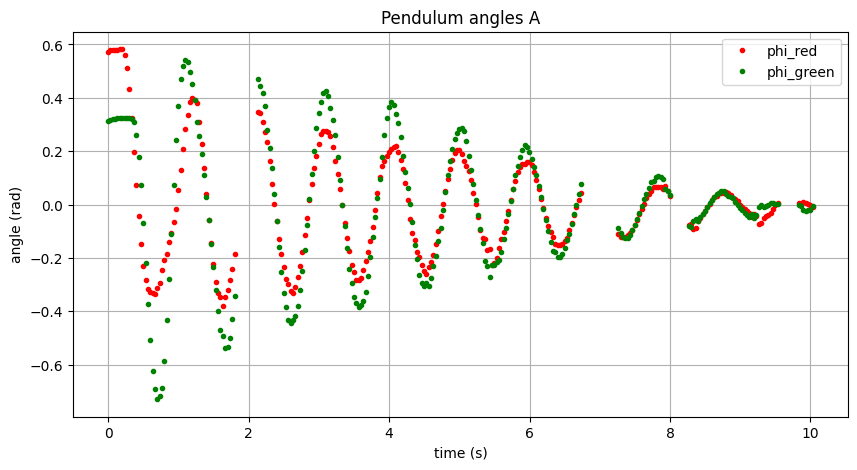

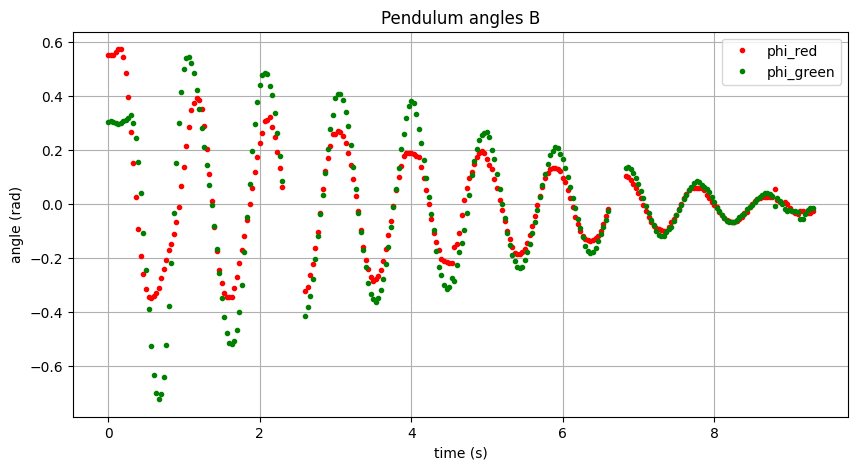

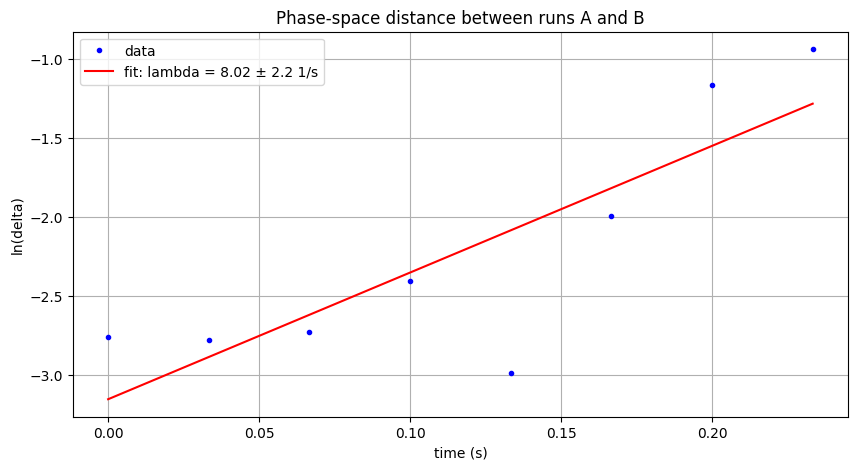

lambda = 8.023 ± 2.2 1/s
time interval for lambda: 0 s to 0.26 s
delta_phi_green = 0.01175
delta_phi_red = 0.02407
delta_p_red = 0.001115
delta_p_green = 0.0002489
initial energy U_0 = -0.6354 J (A: -0.6313 J, B: -0.6395 J)


,time_s,delta,ln_delta
0,0.000000,0.063143,-2.762350
1,0.033328,0.061934,-2.781681
2,0.066656,0.065370,-2.727693
3,0.099984,0.090186,-2.405883
4,0.133312,0.050325,-2.989262
...,...,...,...
281,9.365183,NaN,NaN
282,9.398511,NaN,NaN
283,9.431839,NaN,NaN
284,9.465167,NaN,NaN


In [24]:
analysed_30, lam_30, lam_30_err, U_0_30 = analyse_pair(analyzed_result_30A, analyzed_result_30B,time_interval=(0,0.26))
analysed_30


===== 30 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_B.csv


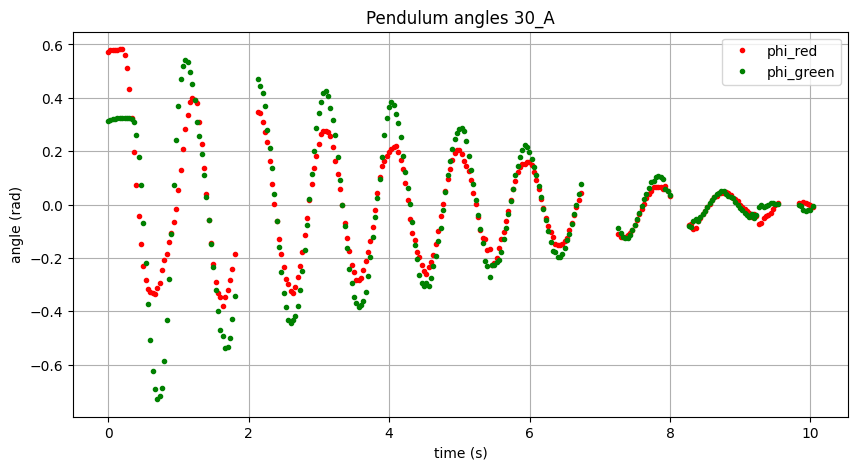

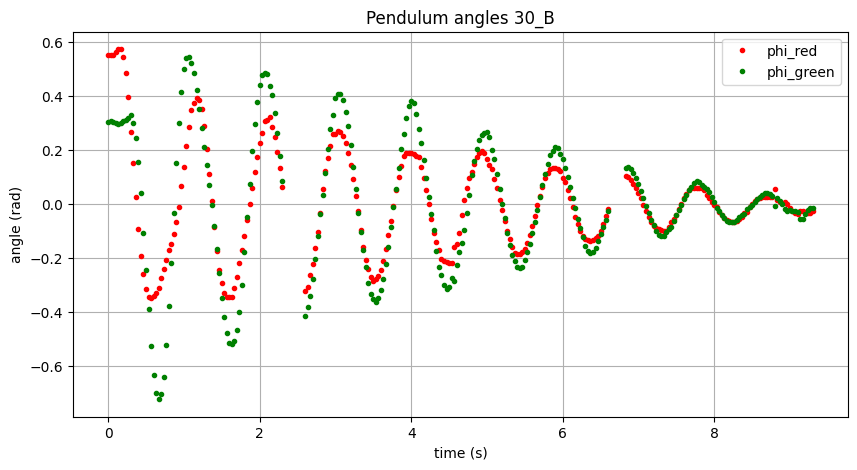

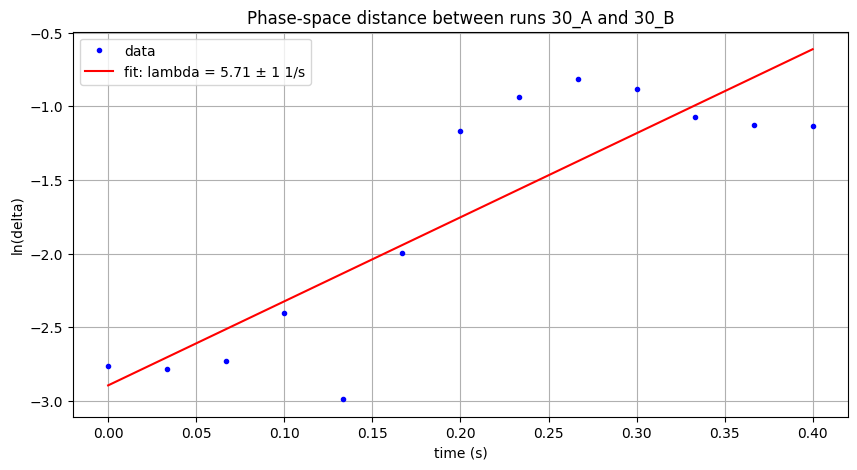

lambda = 5.708 ± 1 1/s
time interval for lambda: 0 s to 0.4 s
delta_phi_green = 0.01175
delta_phi_red = 0.02407
delta_p_red = 0.001115
delta_p_green = 0.0002489
initial energy U_0 = -0.6354 J (A: -0.6313 J, B: -0.6395 J)
===== 40 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\40_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\40_B.csv


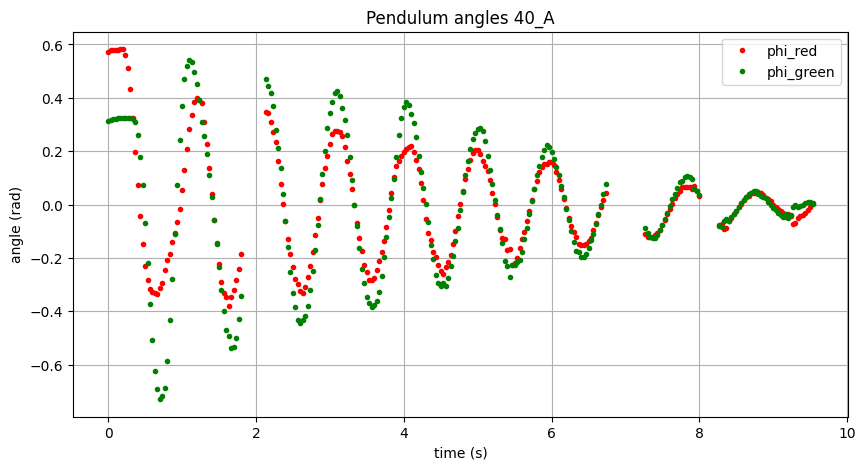

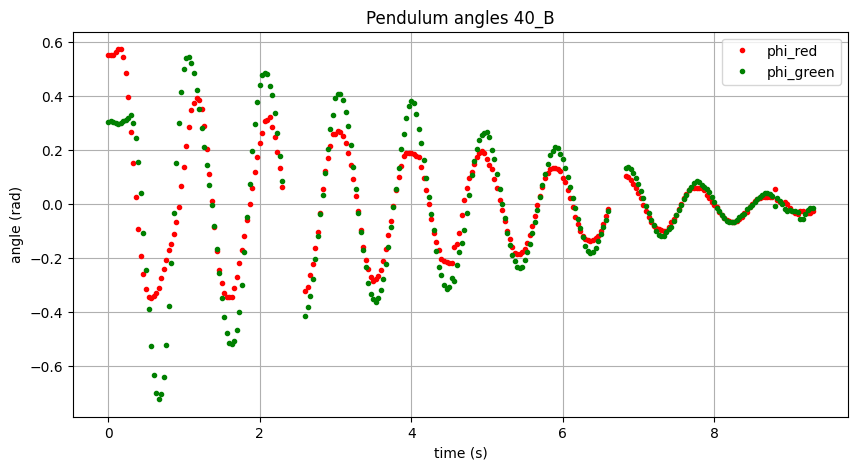

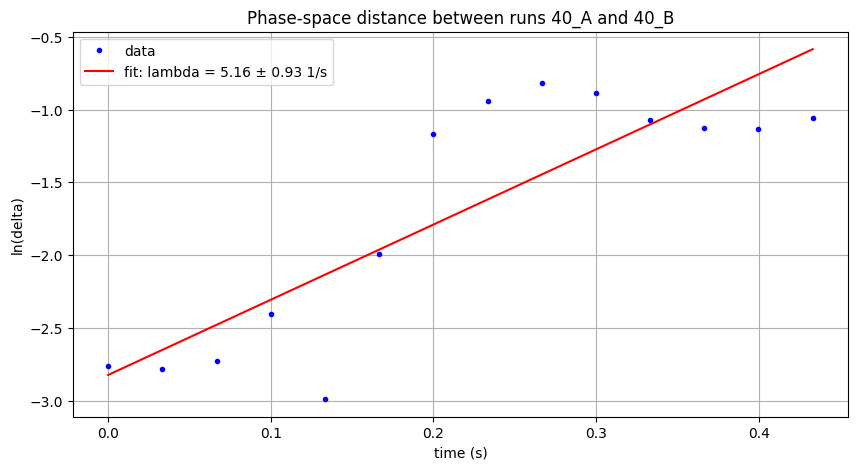

lambda = 5.162 ± 0.93 1/s
time interval for lambda: 0 s to 0.45 s
delta_phi_green = 0.01175
delta_phi_red = 0.02407
delta_p_red = 0.001115
delta_p_green = 0.0002489
initial energy U_0 = -0.6354 J (A: -0.6313 J, B: -0.6395 J)
===== 50 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\50_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\50_B.csv


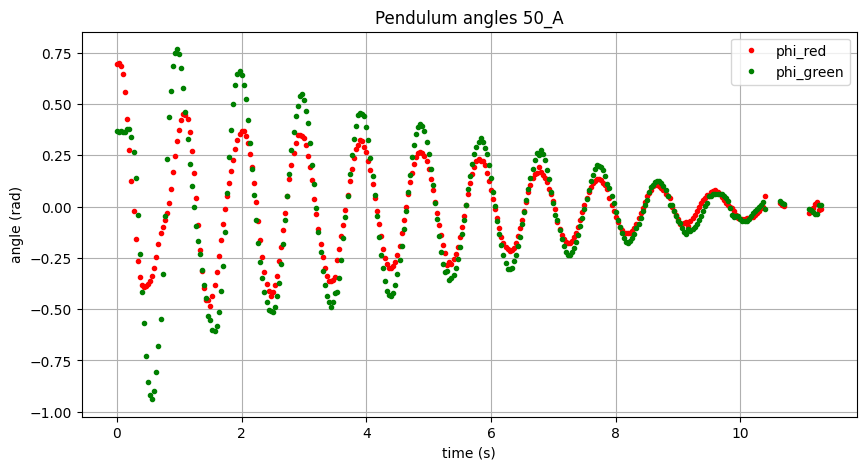

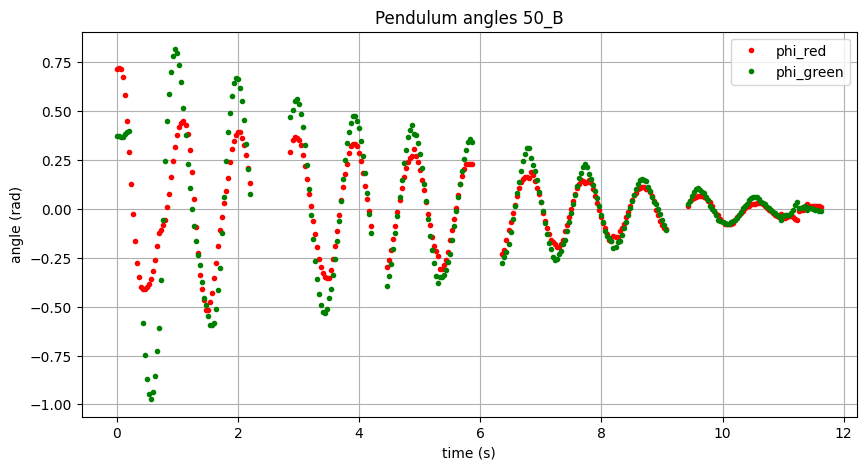

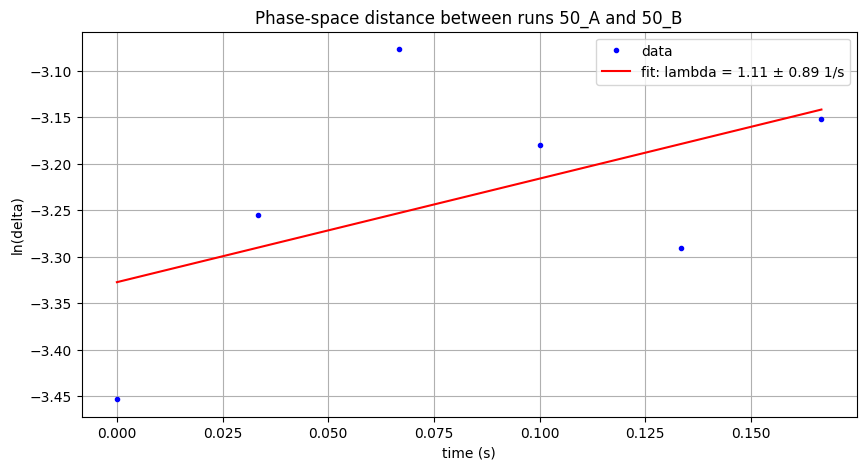

lambda = 1.114 ± 0.89 1/s
time interval for lambda: 0 s to 0.3 s
delta_phi_green = -0.005223
delta_phi_red = -0.02136
delta_p_red = 0.0001659
delta_p_green = -9.115e-05
initial energy U_0 = -0.5815 J (A: -0.5858 J, B: -0.5772 J)
===== 60 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\60_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\60_B.csv


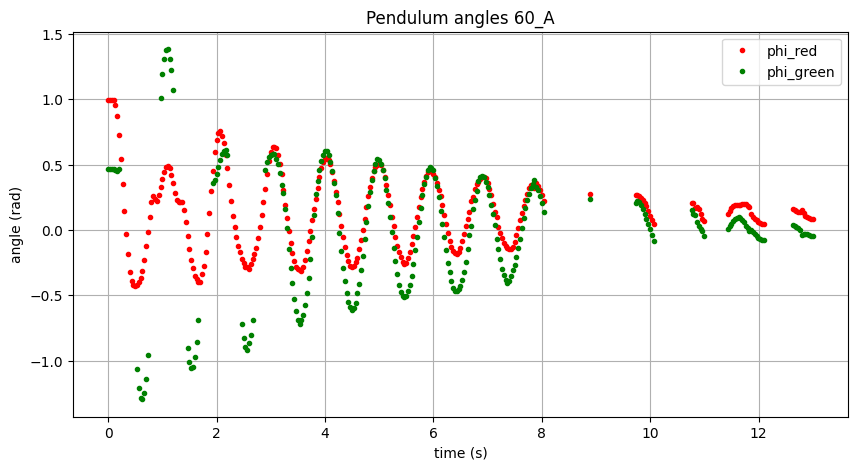

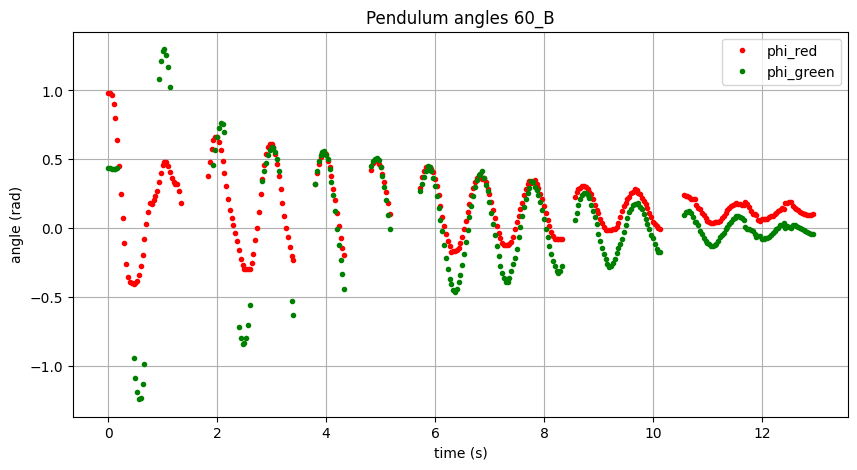

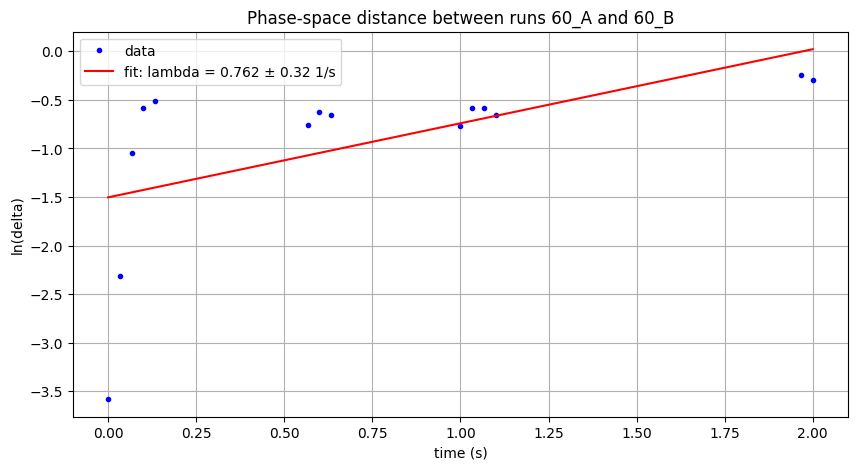

lambda = 0.7624 ± 0.32 1/s
time interval for lambda: 0 s to 2 s
delta_phi_green = 0.03406
delta_phi_red = 0.01298
delta_p_red = 0
delta_p_green = 0
initial energy U_0 = -0.4504 J (A: -0.4462 J, B: -0.4547 J)
===== 70 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\70_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\70_B.csv


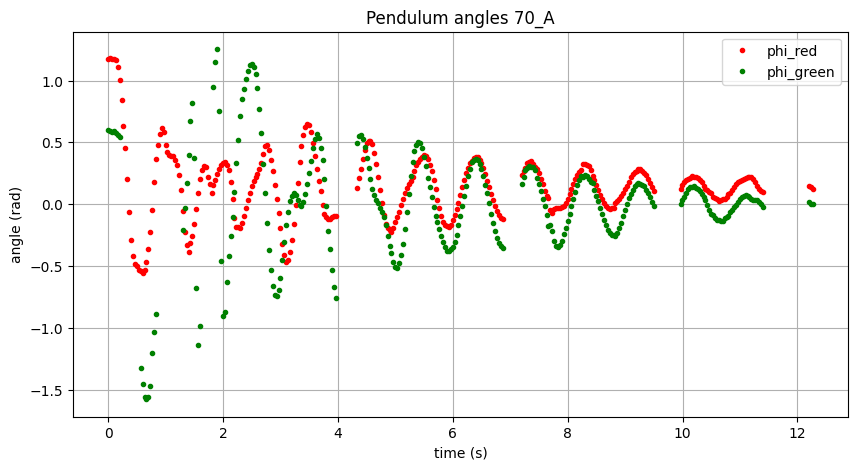

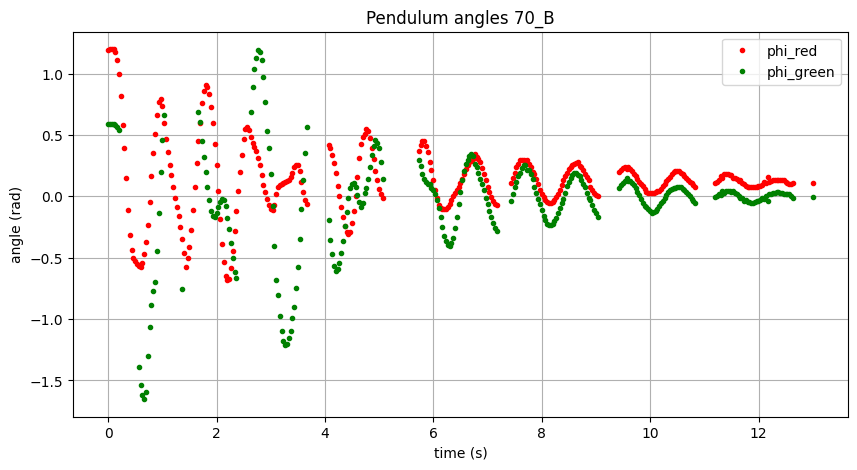

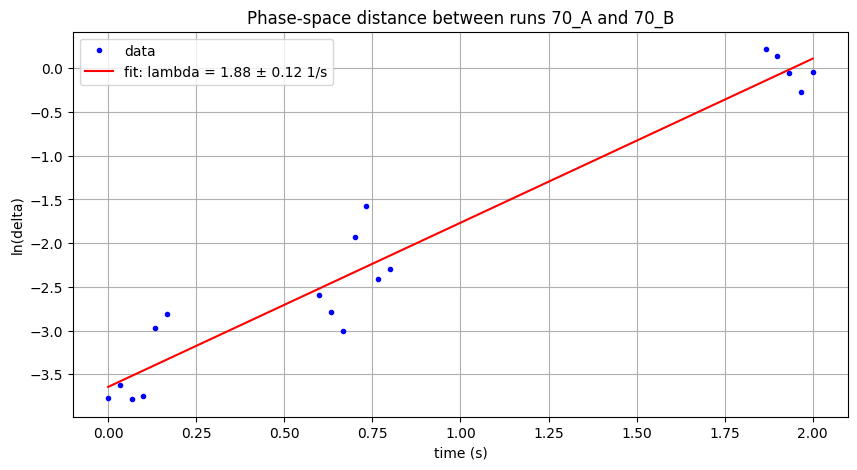

lambda = 1.878 ± 0.12 1/s
time interval for lambda: 0 s to 2 s
delta_phi_green = 0.007183
delta_phi_red = -0.01789
delta_p_red = -0.0006807
delta_p_green = -0.000256
initial energy U_0 = -0.3369 J (A: -0.3416 J, B: -0.3323 J)
===== 80 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\80_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\80_B.csv


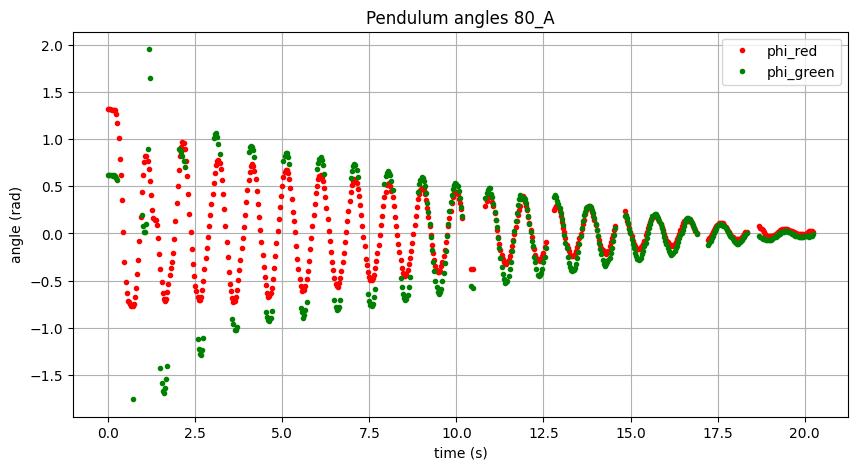

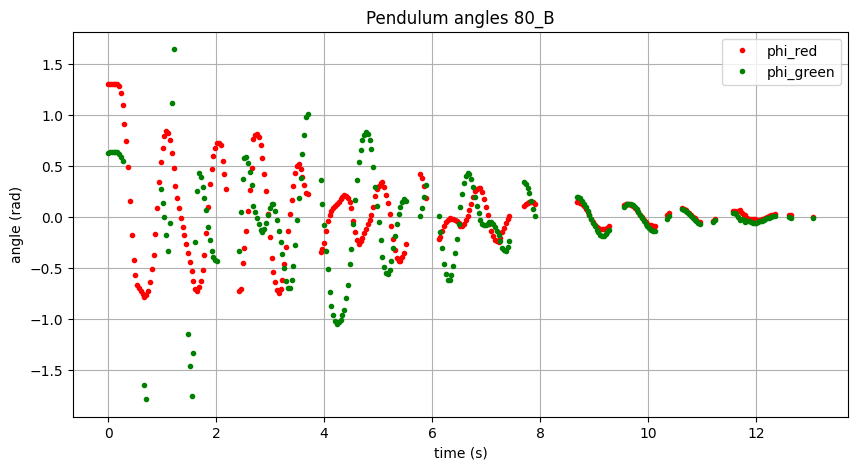

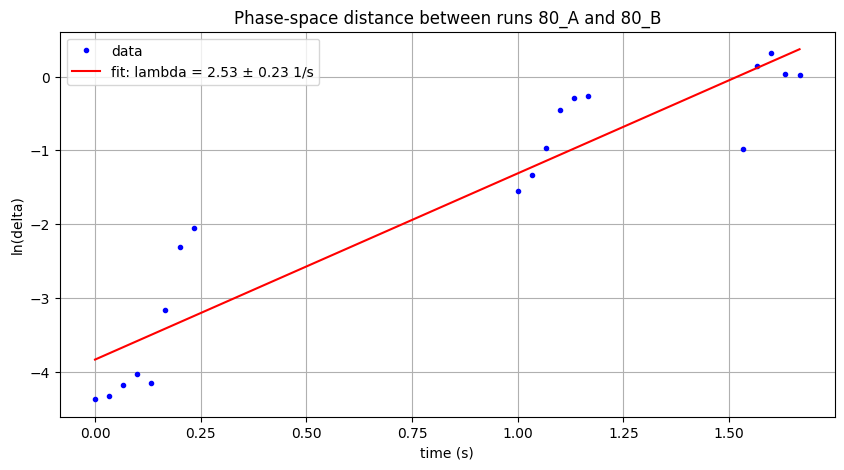

lambda = 2.525 ± 0.23 1/s
time interval for lambda: 0 s to 2 s
delta_phi_green = -0.01622
delta_phi_red = 0.01157
delta_p_red = -0.0001015
delta_p_green = -7.046e-05
initial energy U_0 = -0.2641 J (A: -0.2614 J, B: -0.2668 J)
===== 90 =====
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\90_A.csv
Loaded existing tracking data: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\90_B.csv


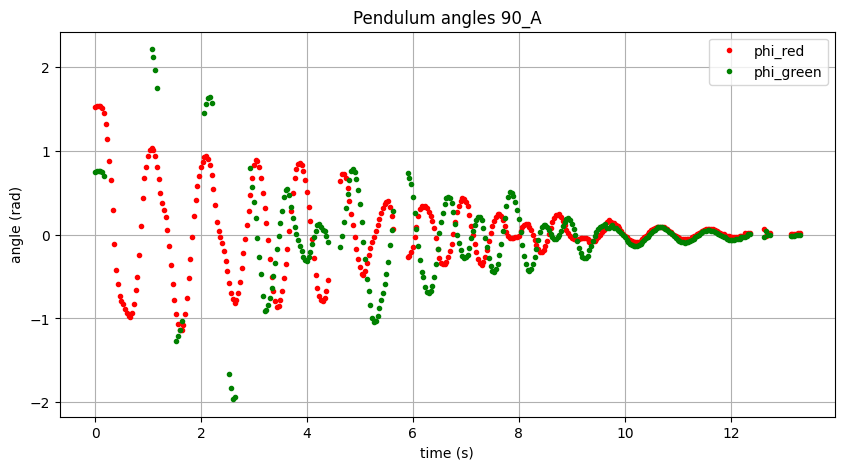

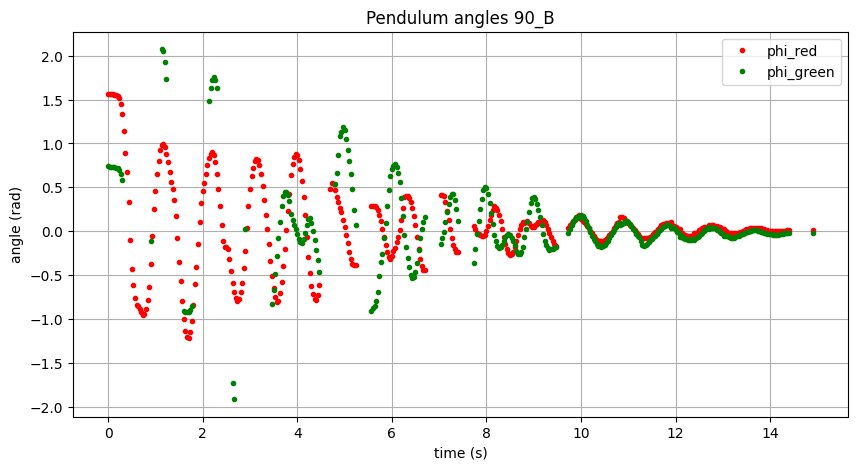

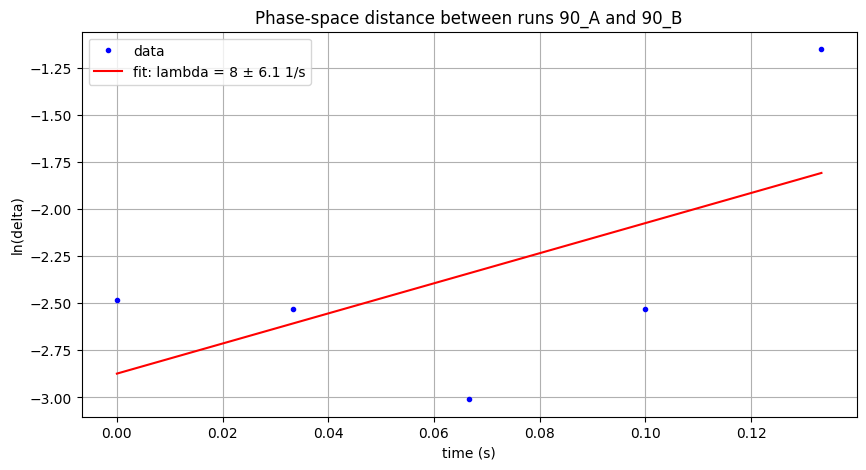

lambda = 8 ± 6.1 1/s
time interval for lambda: 0 s to 2 s
delta_phi_green = 0.008747
delta_phi_red = -0.03724
delta_p_red = 0.002199
delta_p_green = 0.0007293
initial energy U_0 = -0.1164 J (A: -0.1271 J, B: -0.1057 J)


,pair,lambda,lambda_err,t_start,t_end,delta_phi_green,delta_phi_red,delta_p_red,delta_p_green,U_0
0,30_A/30_B,5.707757,1.023216,0,0.40,0.011751,0.024067,0.001115,0.000249,-0.635399
1,40_A/40_B,5.161961,0.931170,0,0.45,0.011751,0.024067,0.001115,0.000249,-0.635399
2,50_A/50_B,1.114488,0.892902,0,0.30,-0.005223,-0.021362,0.000166,-0.000091,-0.581505
3,60_A/60_B,0.762404,0.323007,0,2.00,0.034059,0.012984,0.000000,0.000000,-0.450438
4,70_A/70_B,1.878043,0.117252,0,2.00,0.007183,-0.017891,-0.000681,-0.000256,-0.336927
5,80_A/80_B,2.525324,0.228701,0,2.00,-0.016222,0.011573,-0.000101,-0.000070,-0.264109
6,90_A/90_B,7.999700,6.117895,0,2.00,0.008747,-0.037237,0.002199,0.000729,-0.116397


In [33]:
DEFAULT_ORIGIN = (1025, 156)  # origin (pixels) used when a video has no 'origin' setting


def run_pair(name_A, name_B, settings_A, settings_B, time_interval=None, preview=True, retrack=False):
    """
    Full workflow for one pair of videos: track both videos, cut them at the release frame,
    compute the angles/momenta and analyse them as a pair.

    name_A, name_B: video names without extension, e.g. '30_A' (videos/<name>.mp4).
    settings_A, settings_B: dicts with 'first_frame' (release frame) and optionally 'origin'
    (origin_x, origin_y) in pixels (default DEFAULT_ORIGIN) and 'last_frame'.
    time_interval: (t_start, t_end) in seconds for the lambda fit, or None to fit all data.
    preview: passed to process_video (show the tracking window).
    retrack: if False (default), an existing videos/<name>.csv is loaded instead of tracking the
    video again; set True to force re-tracking.

    Returns: dict with the results of analyse_pair and the initial separations.
    """
    analyzed = []
    for name, s in ((name_A, settings_A), (name_B, settings_B)):
        origin = s.get('origin', DEFAULT_ORIGIN)
        csv_path = root / 'videos' / f'{name}.csv'
        if csv_path.exists() and not retrack:
            print(f'Loaded existing tracking data: {csv_path}')
            res = pd.read_csv(csv_path)
        else:
            res = process_video(
                video_path=root / 'videos' / f'{name}.mp4',
                output_csv=csv_path,
                preview=preview,
                save_annotated=True,
            )
        analyzed.append(analyze_video(
            res, s['first_frame'], s.get('last_frame'), scale=scale,
            origin_x=origin[0], origin_y=origin[1],
        ))
    df_A, df_B = analyzed

    joined, lam, lam_err, U_0 = analyse_pair(df_A, df_B, name_A, name_B, time_interval=time_interval)

    return {
        'pair': f'{name_A}/{name_B}',
        'lambda': lam,
        'lambda_err': lam_err,
        't_start': time_interval[0] if time_interval else None,
        't_end': time_interval[1] if time_interval else None,
        **{f'delta_{v}': df_A[v].iloc[0] - df_B[v].iloc[0]
           for v in ('phi_green', 'phi_red', 'p_red', 'p_green')},
        'U_0': U_0,
    }


def run_all_pairs(pairs, preview=True, output_csv=None, time_intervals=None, retrack=False):
    """
    Run run_pair for every entry of pairs (dict: pair name -> dict with keys 'A', 'B' (video
    name and settings) and optionally 'time_interval'). A failing pair is reported and skipped.

    time_intervals: optional override of the fit interval(s) without editing pairs and without
    re-tracking. Either a single (t_start, t_end) applied to all pairs, or a dict pair name ->
    (t_start, t_end) (pairs not in the dict keep their own 'time_interval').
    retrack: False (default) reuses the saved tracking CSVs; True tracks all videos again.

    Returns a dataframe with one row per pair; saved to output_csv if given.
    """
    rows = []
    for key, p in pairs.items():
        print(f'===== {key} =====')
        if isinstance(time_intervals, dict):
            interval = time_intervals.get(key, p.get('time_interval'))
        elif time_intervals is not None:
            interval = time_intervals
        else:
            interval = p.get('time_interval')
        try:
            rows.append(run_pair(
                p['A']['video'], p['B']['video'], p['A'], p['B'],
                time_interval=interval, preview=preview, retrack=retrack,
            ))
        except Exception as e:
            print(f'Pair {key} failed: {e!r}')
    summary = pd.DataFrame(rows)
    if output_csv is not None:
        summary.to_csv(output_csv, index=False)
    return summary


# Settings per pair. Add one entry per pair of videos; origins and release frames are read off
# the first frames. Start with time_interval=None, then fill in the interval after viewing the plot.
pairs = {
    '30': {
        'A': {'video': '30_A', 'first_frame': 22, 'origin': (1025, 156)},
        'B': {'video': '30_B', 'first_frame': 20, 'last_frame': 305, 'origin': (1026, 156)},
        'time_interval': (0, 0.4),
    },
    '40': {
            'A': {'video': '40_A', 'first_frame': 22, 'last_frame':312, 'origin': (1025, 156)},
            'B': {'video': '40_B', 'first_frame': 20, 'last_frame': 309, 'origin': (1026, 156)},
            'time_interval': (0,0.45),
        },
    '50': {
                'A': {'video': '50_A', 'first_frame': 38, 'last_frame':382, 'origin': (1025, 156)},
                'B': {'video': '50_B', 'first_frame': 63, 'last_frame': 412, 'origin': (1026, 156)},
                'time_interval': (0,0.3),
            },
    '60': {
                'A': {'video': '60_A', 'first_frame': 33, 'last_frame':428, 'origin': (1025, 156)},
                'B': {'video': '60_B', 'first_frame': 34, 'last_frame': 423, 'origin': (1026, 156)},
                'time_interval': (0,2),
            },
    '70': {
                'A': {'video': '70_A', 'first_frame': 15, 'last_frame':402, 'origin': (1025, 156)},
                'B': {'video': '70_B', 'first_frame': 47, 'last_frame': 442, 'origin': (1026, 156)},
                'time_interval': (0,2),
            },
    '80': {
                'A': {'video': '80_A', 'first_frame': 47, 'last_frame':654, 'origin': (1025, 156)},
                'B': {'video': '80_B', 'first_frame': 17, 'last_frame': 414, 'origin': (1026, 156)},
                'time_interval': (0, 2),
            },
    '90': {
                'A': {'video': '90_A', 'first_frame': 40, 'last_frame':440, 'origin': (1025, 156)},
                'B': {'video': '90_B', 'first_frame': 24,'origin': (1026, 156)},
                'time_interval': (0, 2),
            },
        
}

# Tracking CSVs are reused, so changing the interval is fast. Examples:
#   time_intervals=(0, 0.5)                -> same interval for all pairs
#   time_intervals={'30': (0, 0.26), '40': (0, 0.4)}  -> per pair
# Pass retrack=True to track the videos again.
summary = run_all_pairs(pairs, preview=False, output_csv=root / 'lambda_summary.csv', time_intervals=None)
summary

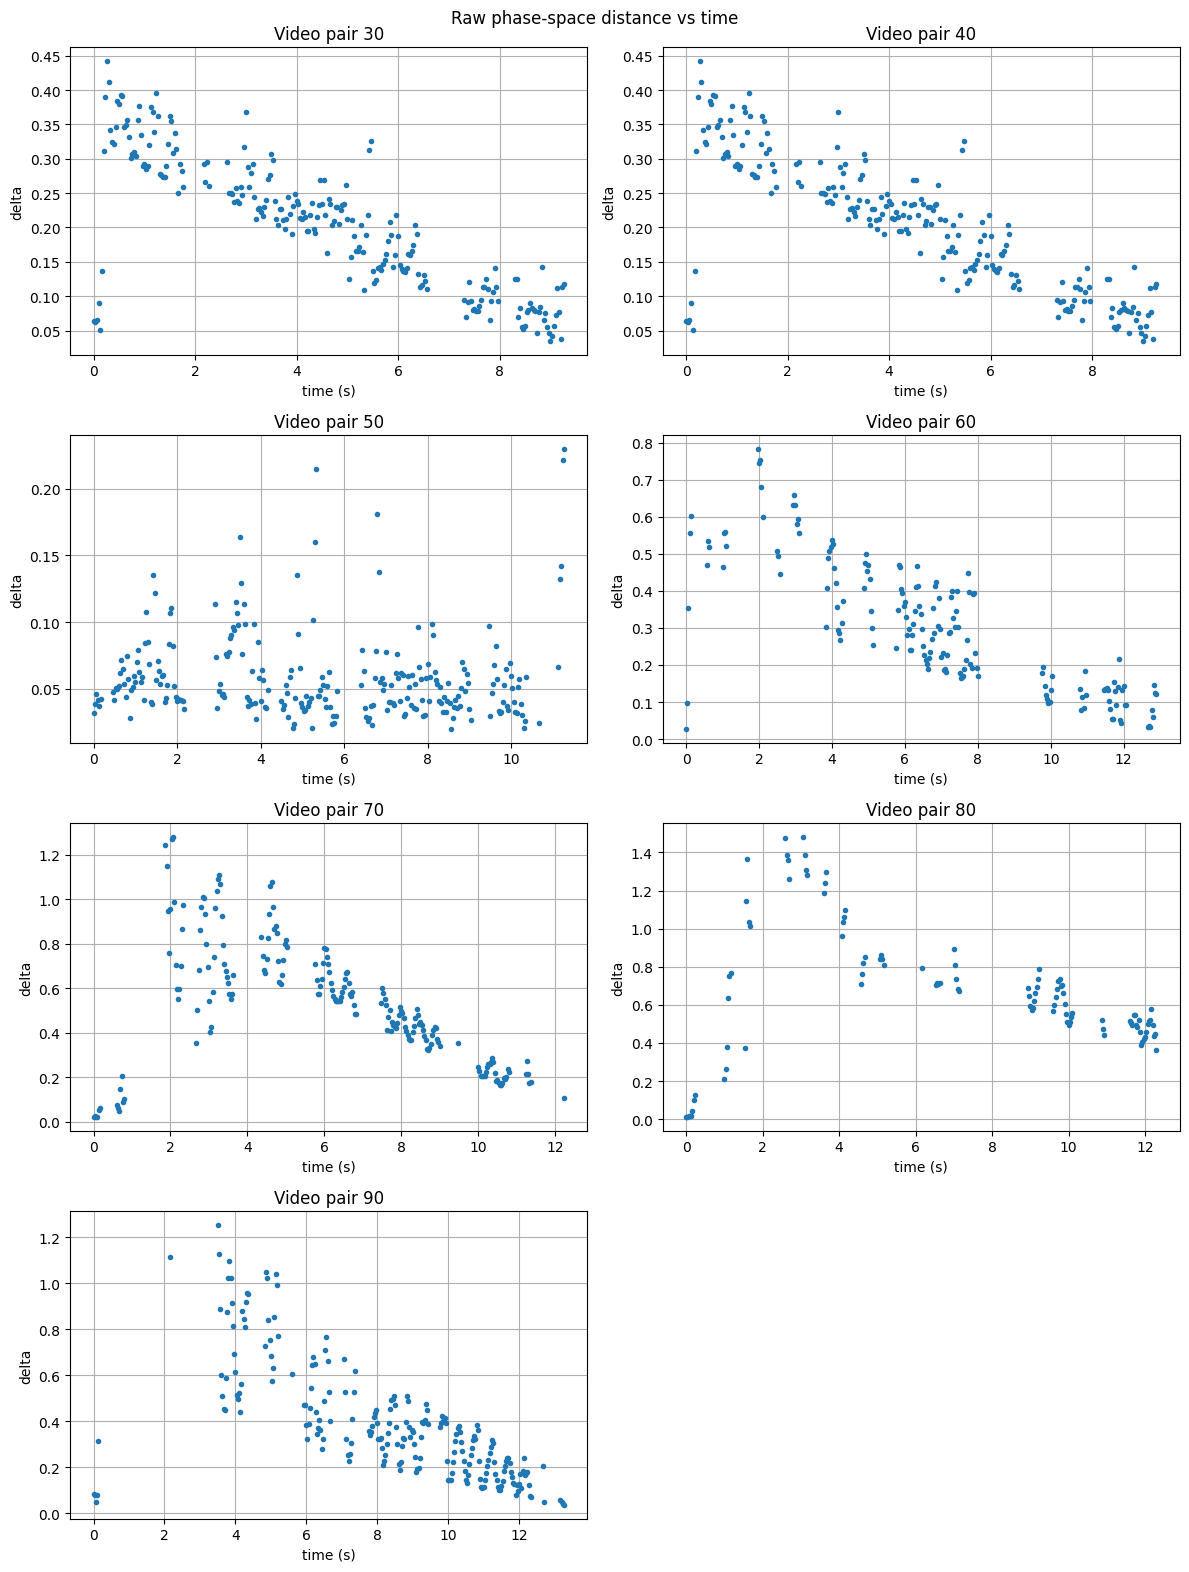

In [26]:
def plot_raw_delta_by_pair(pair_settings=pairs, ncols=2):
    """Plot the unlogged phase-space distance (delta) against time for each video pair."""
    if not pair_settings:
        raise ValueError("pair_settings must contain at least one video pair")
    if ncols < 1:
        raise ValueError("ncols must be at least 1")

    nrows = (len(pair_settings) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False
    )
    joined_by_pair = {}

    for ax, (pair_name, settings) in zip(axes.flat, pair_settings.items()):
        analyzed_runs = []
        for run in (settings["A"], settings["B"]):
            result = pd.read_csv(root / "videos" / f"{run['video']}.csv")
            origin = run.get("origin", DEFAULT_ORIGIN)
            analyzed_runs.append(
                analyze_video(
                    result,
                    run["first_frame"],
                    run.get("last_frame"),
                    scale=scale,
                    origin_x=origin[0],
                    origin_y=origin[1],
                )
            )

        joined = join_runs(
            analyzed_runs[0],
            analyzed_runs[1],
            label_A=settings["A"]["video"],
            label_B=settings["B"]["video"],
        )
        joined_by_pair[pair_name] = joined
        ax.plot(joined["time_s"], joined["delta"], ".")
        ax.set_title(f"Video pair {pair_name}")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("delta")
        ax.grid(True)

    for ax in axes.flat[len(pair_settings):]:
        ax.set_visible(False)

    fig.suptitle("Raw phase-space distance vs time")
    fig.tight_layout()
    plt.show()
    return joined_by_pair


raw_delta_by_pair = plot_raw_delta_by_pair(pairs)

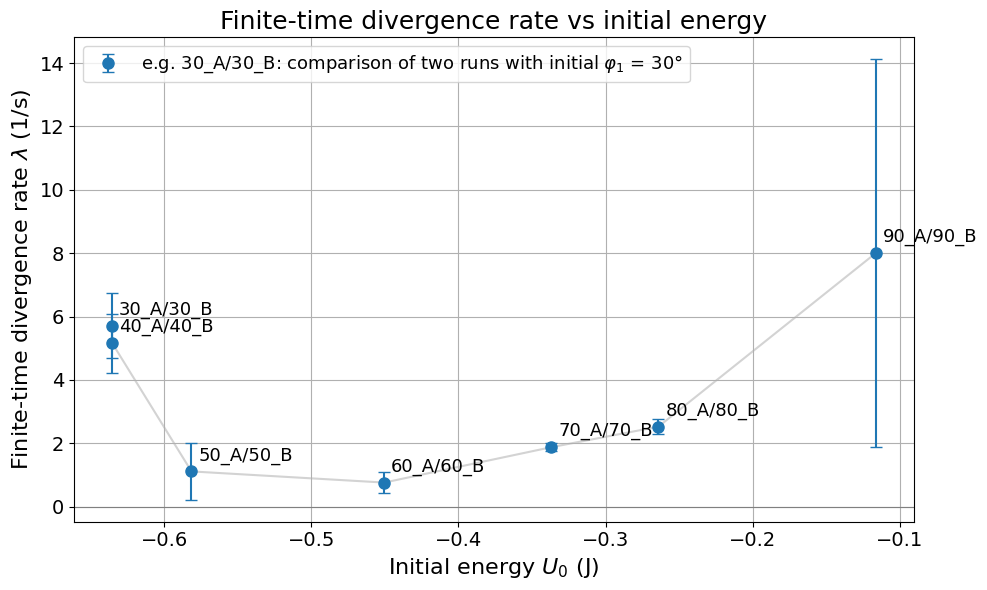

In [38]:
def plot_lambda_vs_energy(summary, title="Finite-time divergence rate vs initial energy"):
    """
    Plot lambda (with error bars) against the initial energy U_0 for every pair in the
    summary dataframe returned by run_all_pairs. Pairs without a valid lambda are skipped.
    """
    data = summary.dropna(subset=['lambda', 'U_0']).sort_values('U_0')

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(data['U_0'], data['lambda'], '-', color='lightgray', zorder=0)
    ax.errorbar(data['U_0'], data['lambda'], yerr=data['lambda_err'], fmt='o', capsize=4,
                markersize=8, color='C0',
                label=r'e.g. 30_A/30_B: comparison of two runs with initial $\varphi_1$ = 30°')
    for _, row in data.iterrows():
        ax.annotate(row['pair'], (row['U_0'], row['lambda']), textcoords='offset points',
                    xytext=(5, 8), fontsize=13)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xlabel('Initial energy $U_0$ (J)', fontsize=16)
    ax.set_ylabel(r'Finite-time divergence rate $\lambda$ (1/s)', fontsize=16)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True)
    ax.legend(fontsize=13)
    fig.tight_layout()
    plt.savefig("../lambda_vs_energy.png",dpi=450)
    plt.show()
    return data


lambda_vs_energy = plot_lambda_vs_energy(summary)

## Discussion

The acquired results are unreliable, because of several factors. First of all, the used frame rate was reset to the standard 30 FPS by the used camera without notification, while the desired FPS was at least 60. Secondly, the markers are often not tracked when they move at high speeds. This results in few measurements just after the release, where the $\lambda$ is fitted from. Thirdly, the time interval at which the systems behave chaotically and the measurements are analysed are short, causing greater uncertainty in the final result. Additionally, other factors such as bad lightning and release with a small initial velocity contribute to slightly incorrect results. 